In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import os

In [11]:
import sys
import importlib

# --- FIX: AUTORELOAD FOR JUPYTER ---
# These lines ensure that when you save changes to logistic_regression.py, 
# the notebook will automatically reload the new code.
%load_ext autoreload
%autoreload 2
# -----------------------------------

proc_libs=['models', 'experiment']

# Now importing DH_OBJ from the logistic_regression package
try:
    # 1. Check if the module is already loaded (cached)
    for proc_lib in proc_libs:
        if proc_lib in sys.modules:
            print(f"Module {proc_lib} found in cache. Forcing reload...")
            importlib.reload(sys.modules[proc_lib])

    # 2. Perform the import (this will use the reloaded or new version)
    from models import ExperimentConfig
    from experiment import ExperimentProcessor, ExperimentPlotter
except ImportError as e:
    print(f"\n[ERROR] Import failed. Ensure your {proc_lib} file are correctly structured.")
    print(f"Details: {e}")
    sys.exit(1)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Module models found in cache. Forcing reload...
Module experiment found in cache. Forcing reload...


# 0. Inputs

In [17]:
# Arguments. Test purpose only
input_dir = "/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-23-01-05-43/"
test_type = "default"
# loads_type = ["idle", "load-net", "load-usb", "load-net-usb"]
loads_type = ["idle", "load-net"]
channels = [0, 1]
nominal_period_us = 200000
duration_s = 60

datasets = []
for load_type in loads_type:
    config = ExperimentConfig(
        input_dir=input_dir,
        test_type=test_type,
        load_type=load_type,
        channels=channels,
        nominal_period_us=nominal_period_us,
        duration_s=duration_s
    )
    datasets.append(ExperimentProcessor(config))

# Load and process data, then generate plots
for dataset in datasets:
    dataset.load_and_process_datas()

Successfully matched graph channel 0 to column 'Channel 0'
Successfully matched graph channel 1 to column 'Channel 1'
Successfully matched graph channel 0 to column 'Channel 0'
Successfully matched graph channel 1 to column 'Channel 1'
Error: The file '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-23-01-05-43/load-net/mpstat_all.log' was not found.


# 1. Jitter plus

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_histogram_default_idle_rise.png'


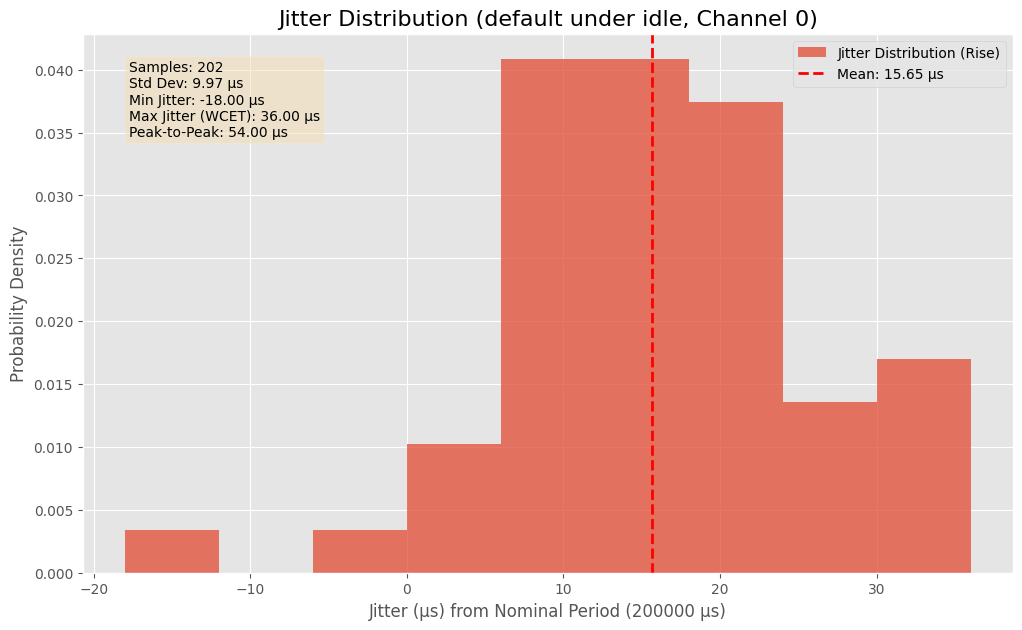

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_histogram_default_idle_fall.png'


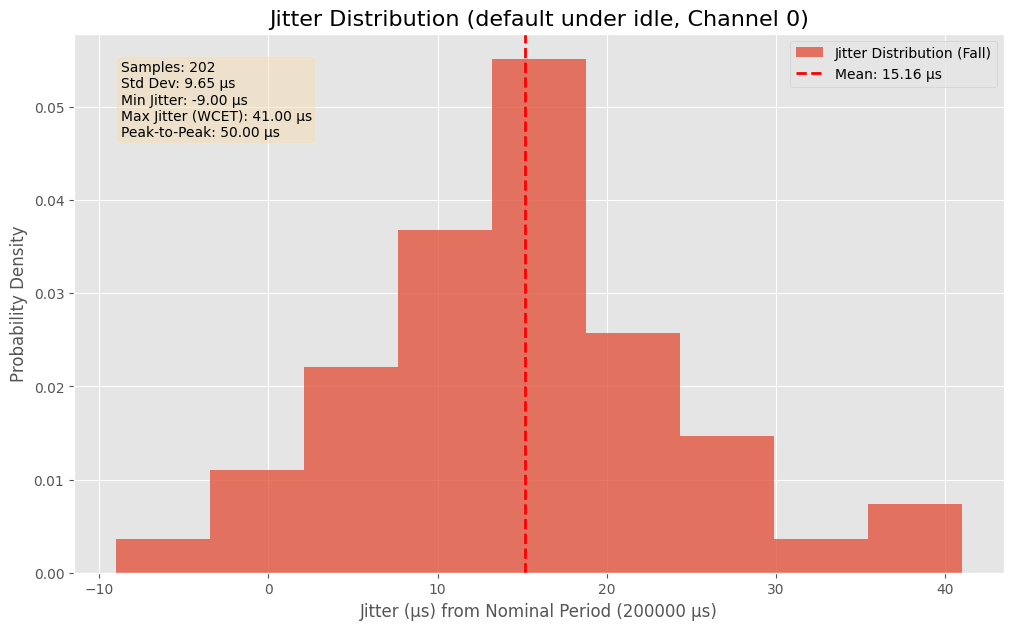

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_histogram_default_idle_rise_fall.png'


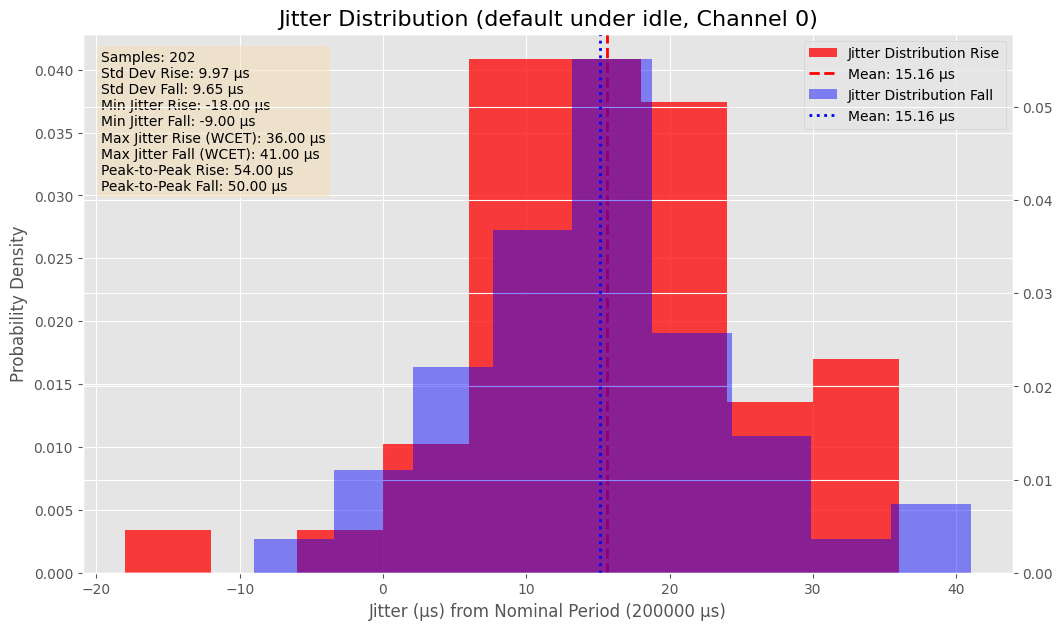

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_histogram_default_idle_rise.png'


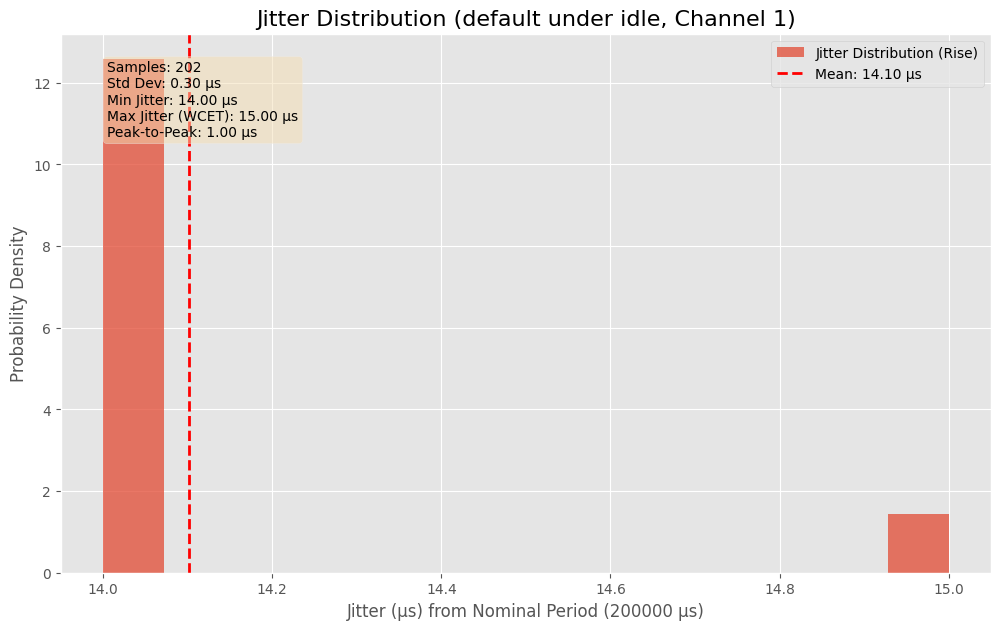

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_histogram_default_idle_fall.png'


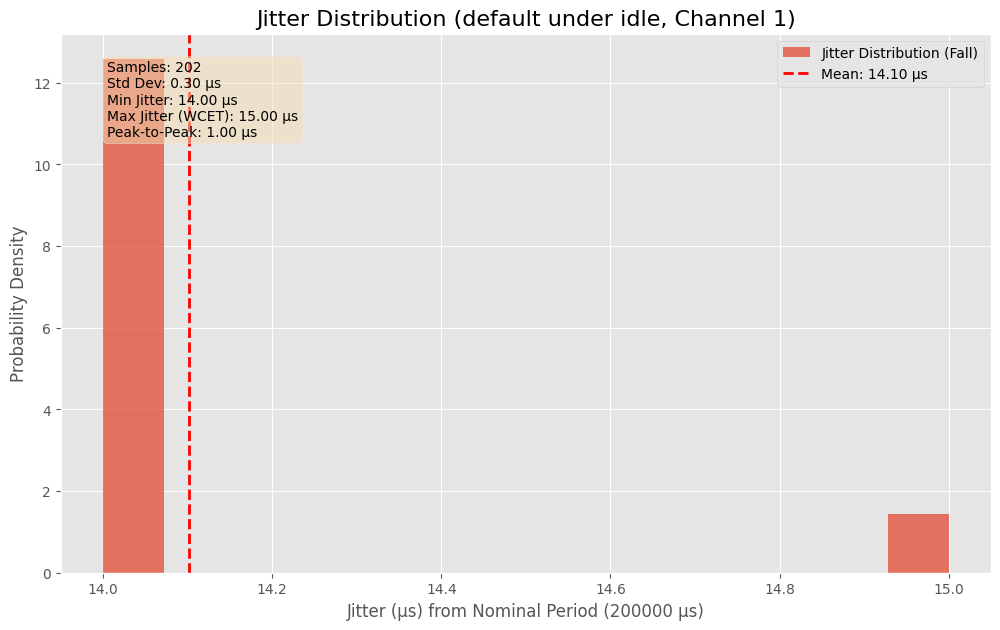

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_histogram_default_idle_rise_fall.png'


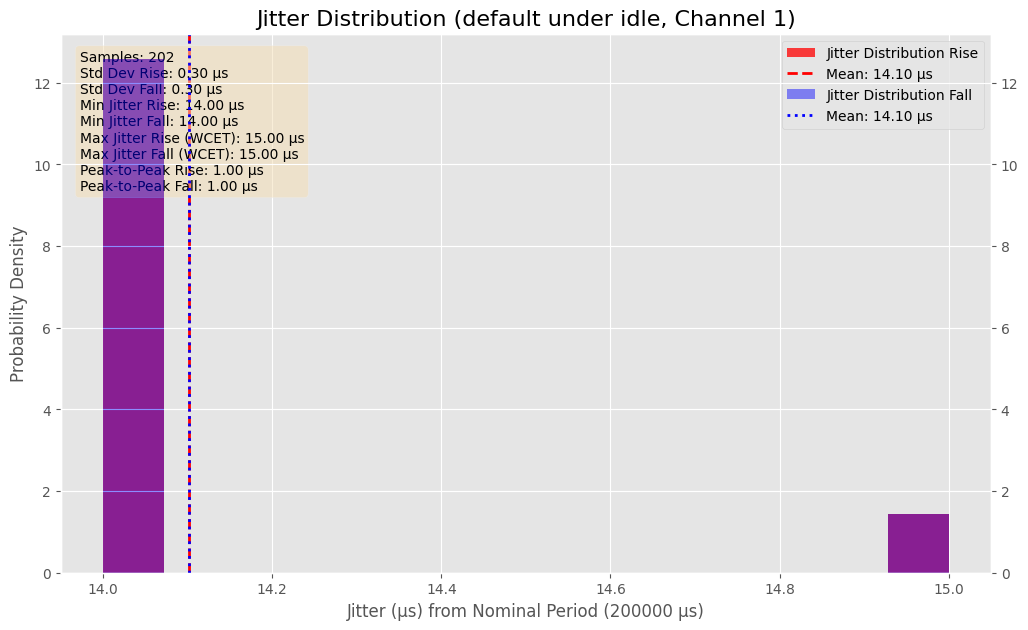

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_histogram_default_idle_cyclic_test.png'


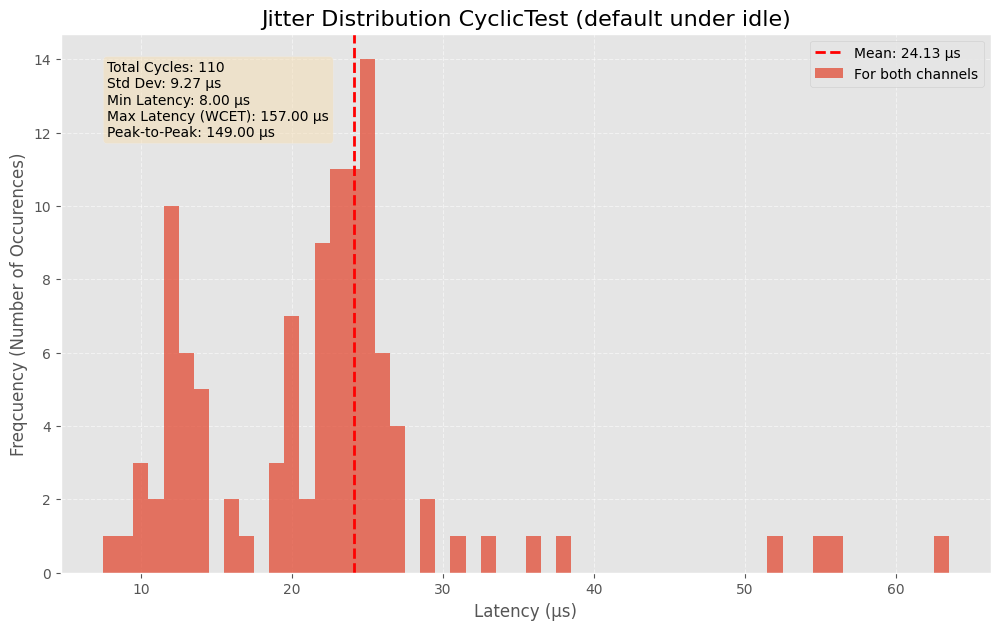

In [4]:
# Plot histogram idle
proc.plot_histograms(plots[0], show=True)

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_histogram_default_load-net_rise.png'


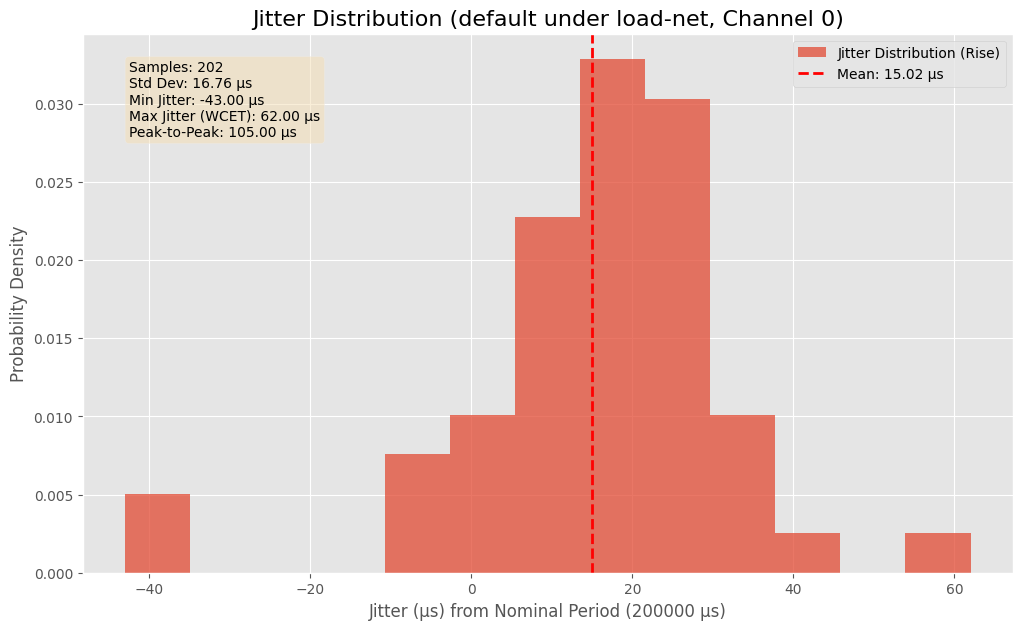

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_histogram_default_load-net_fall.png'


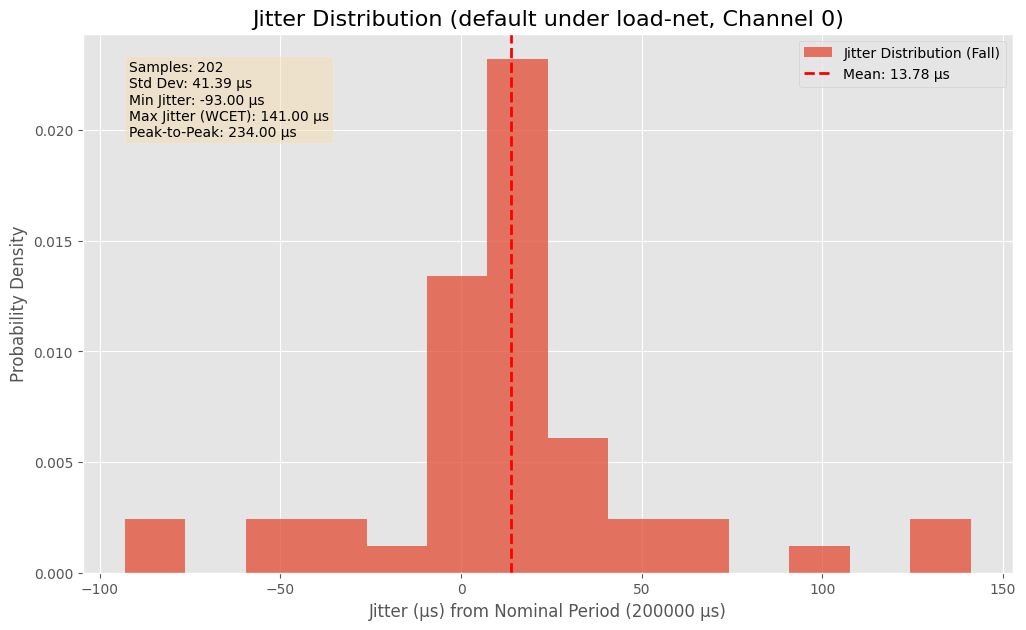

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_histogram_default_load-net_rise_fall.png'


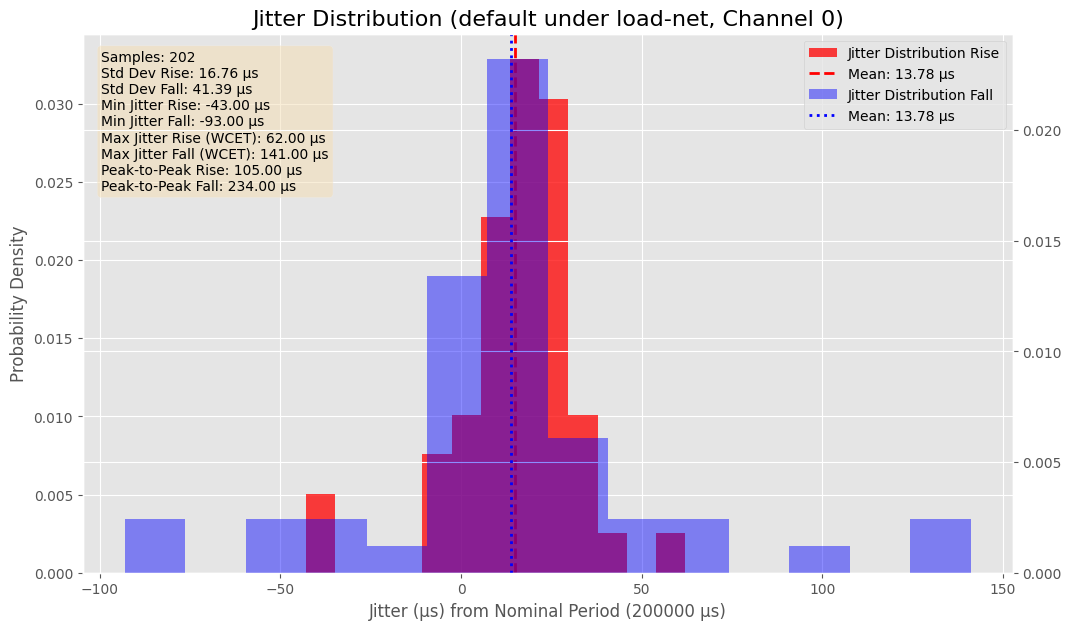

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_histogram_default_load-net_rise.png'


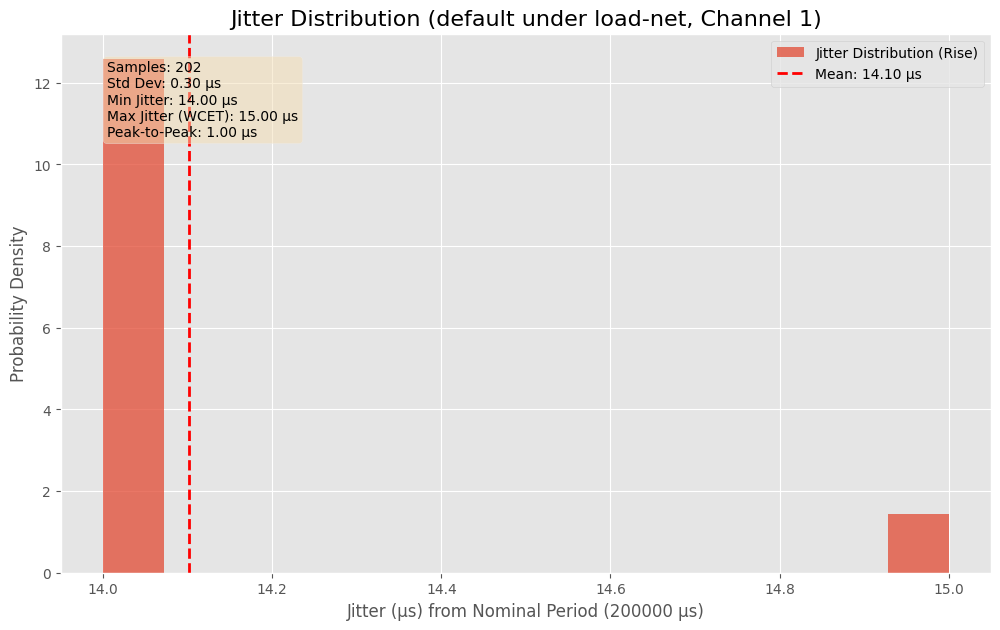

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_histogram_default_load-net_fall.png'


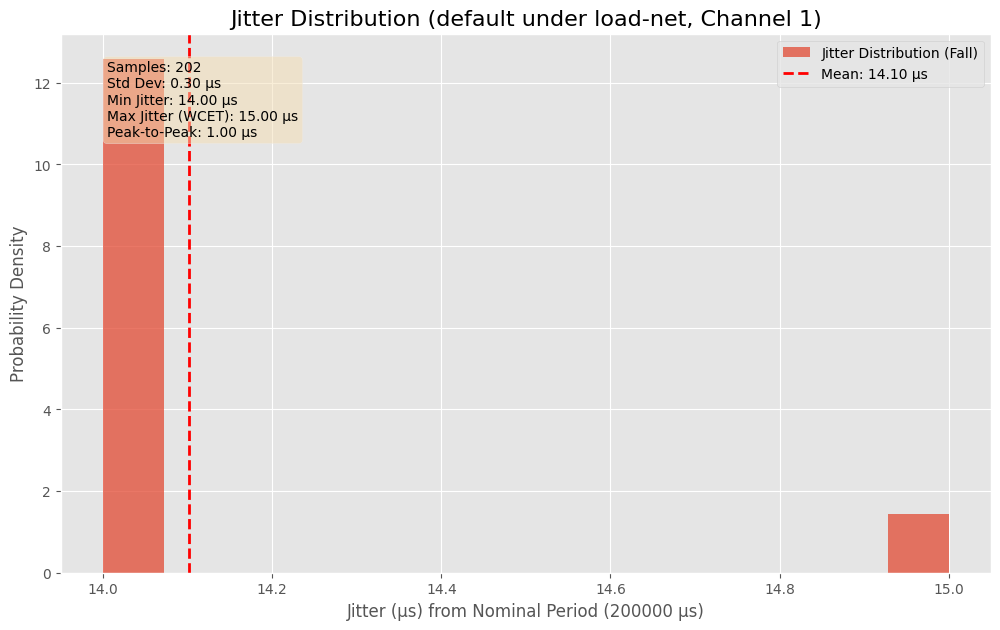

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_histogram_default_load-net_rise_fall.png'


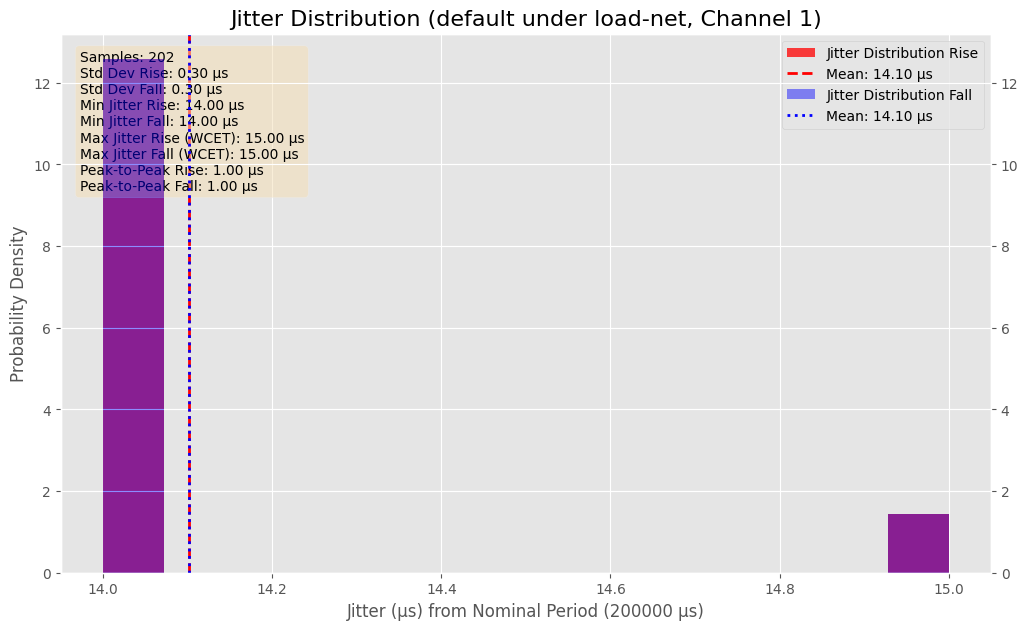

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_histogram_default_load-net_cyclic_test.png'


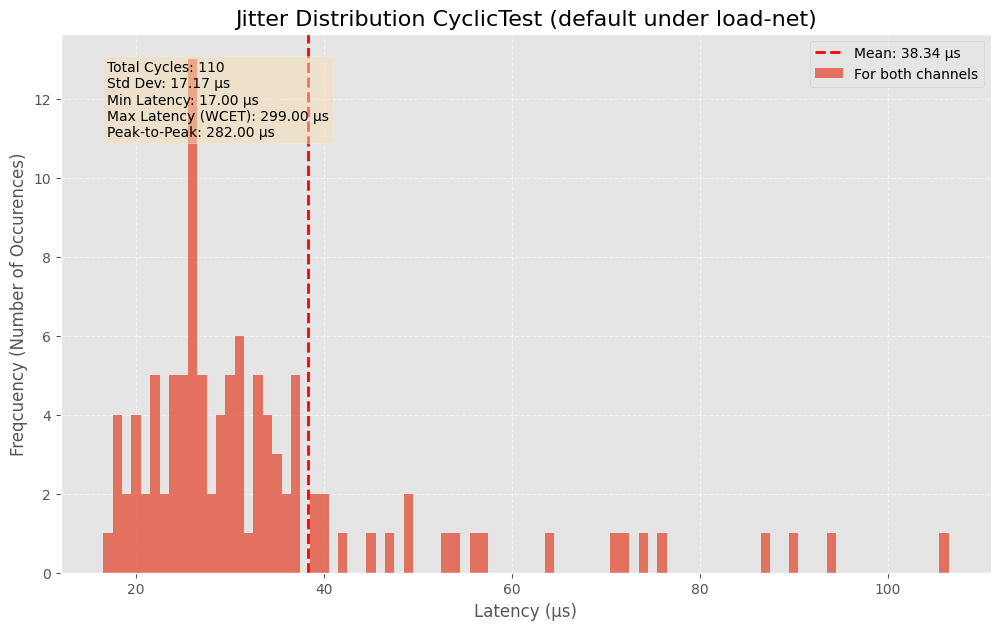

In [5]:
# Plot histogram load
proc.plot_histograms(plots[1], show=True)

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_phase_shift_default_idle.png'


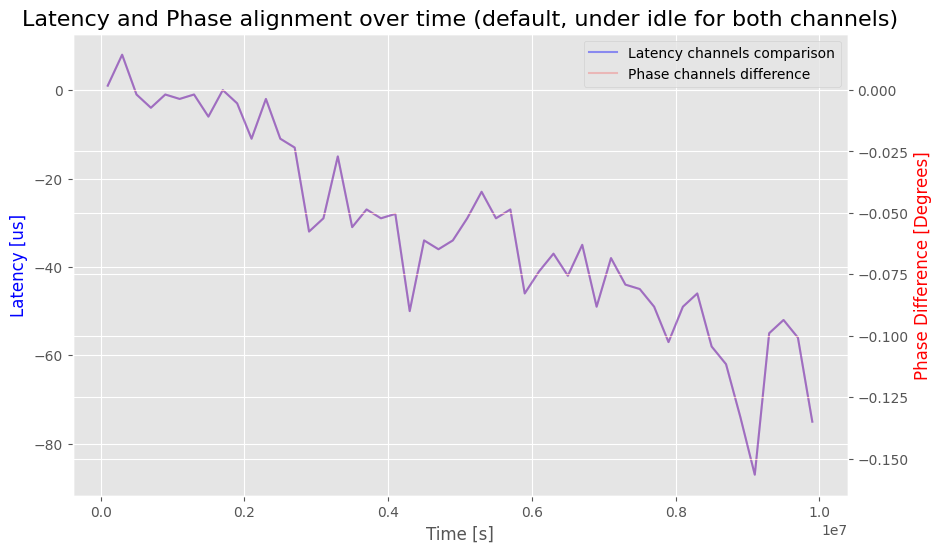

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_phase_shift_default_load-net.png'


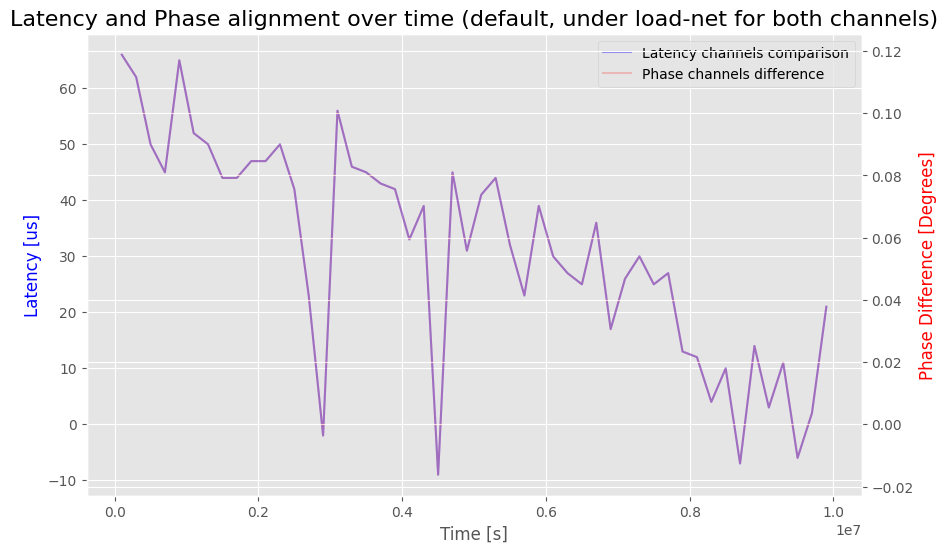

In [6]:
proc.plot_phase_shift_combined(plots[0], show=True)
proc.plot_phase_shift_combined(plots[1], show=True)

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_signal_drift_default_idle_rise_fall_0.png'


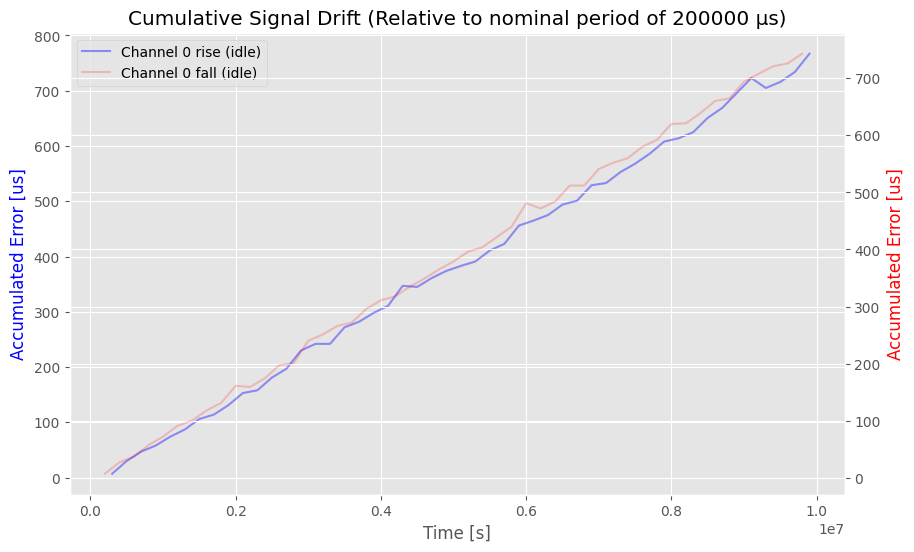

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_signal_drift_default_idle_rise_fall_1.png'


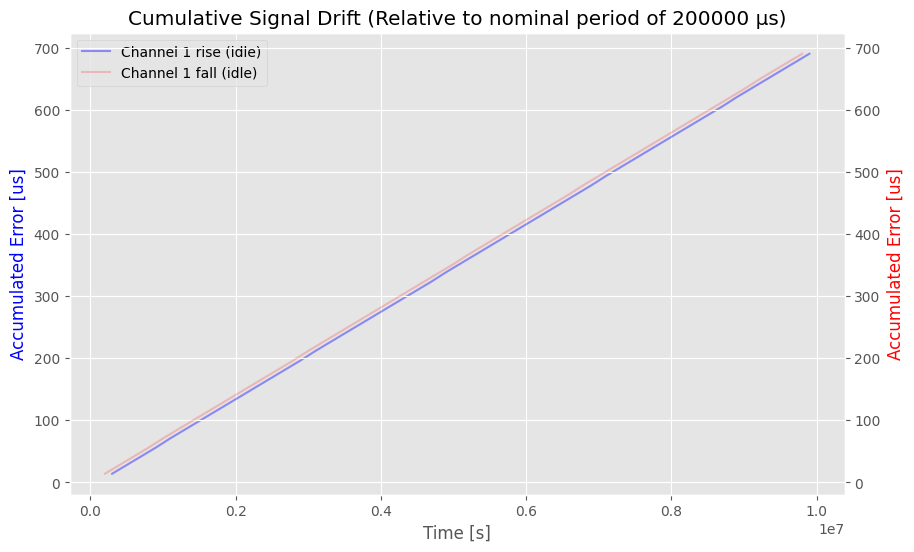

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_signal_drift_default_load-net_rise_fall_0.png'


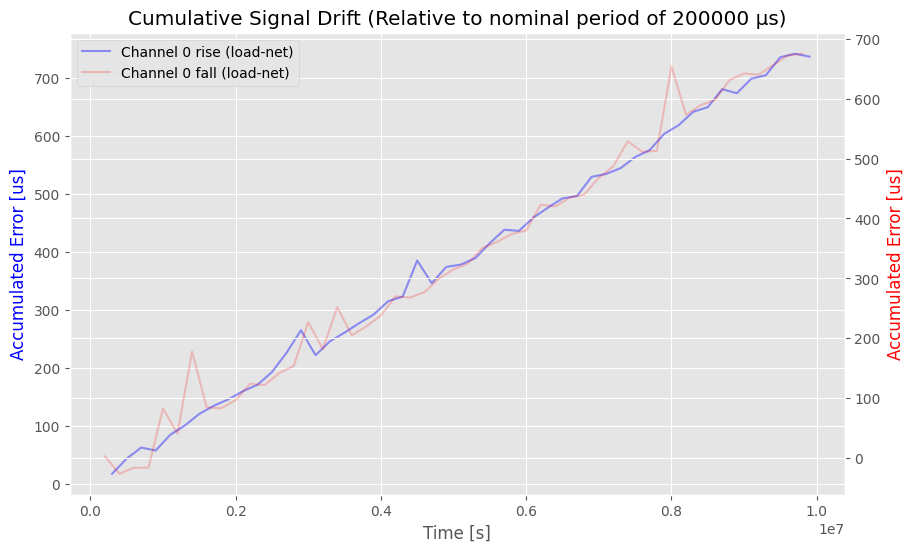

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_signal_drift_default_load-net_rise_fall_1.png'


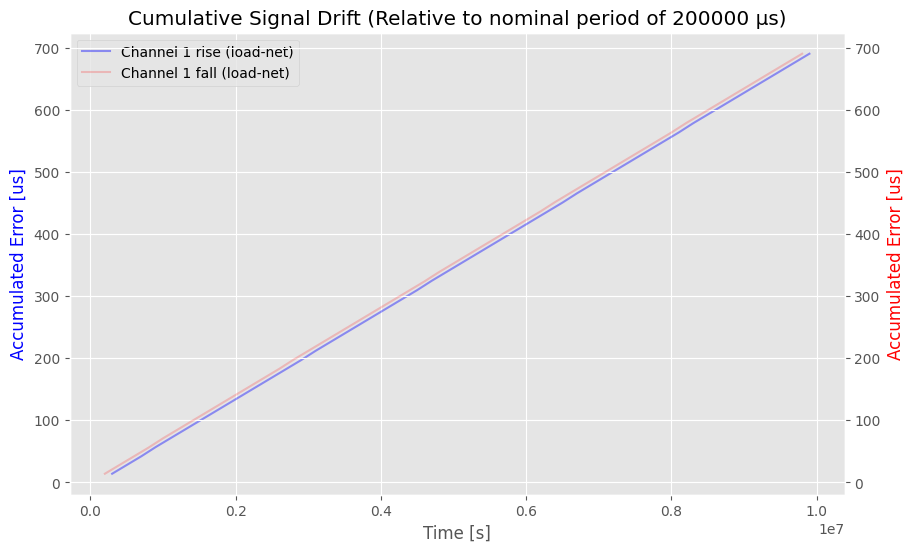

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_signal_drift_default_idle_0_1.png'


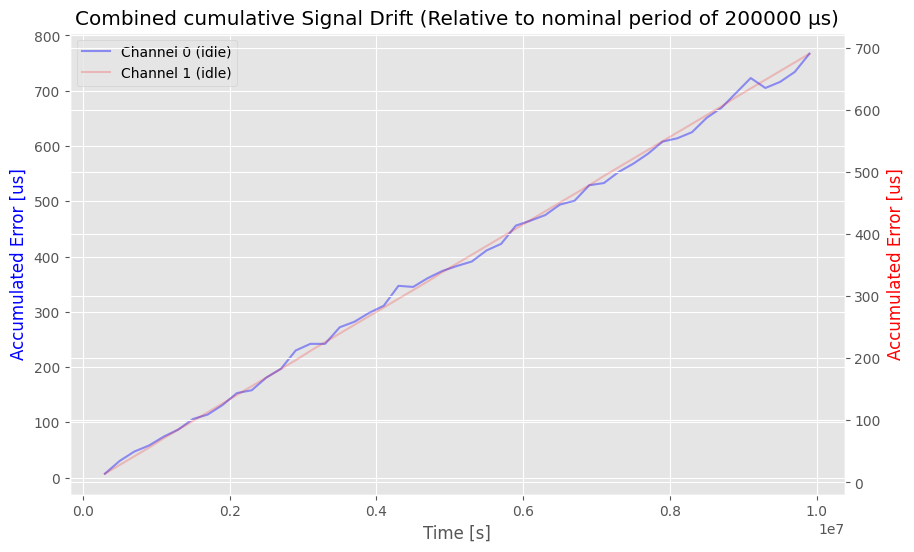

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_signal_drift_default_load-net_0_1.png'


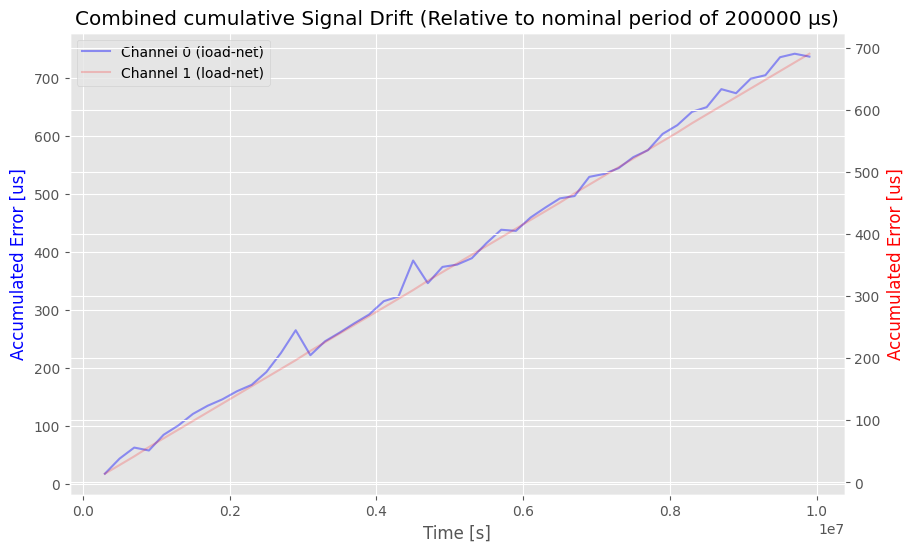

In [7]:
# Individual
proc.plot_signal_drift(plots[0], show=True)
proc.plot_signal_drift(plots[1], show=True)

# Combined
proc.plot_signal_drift_combined(plots[0], show=True)
proc.plot_signal_drift_combined(plots[1], show=True)

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_duty_cycle_default_idle_load-net_0.png'


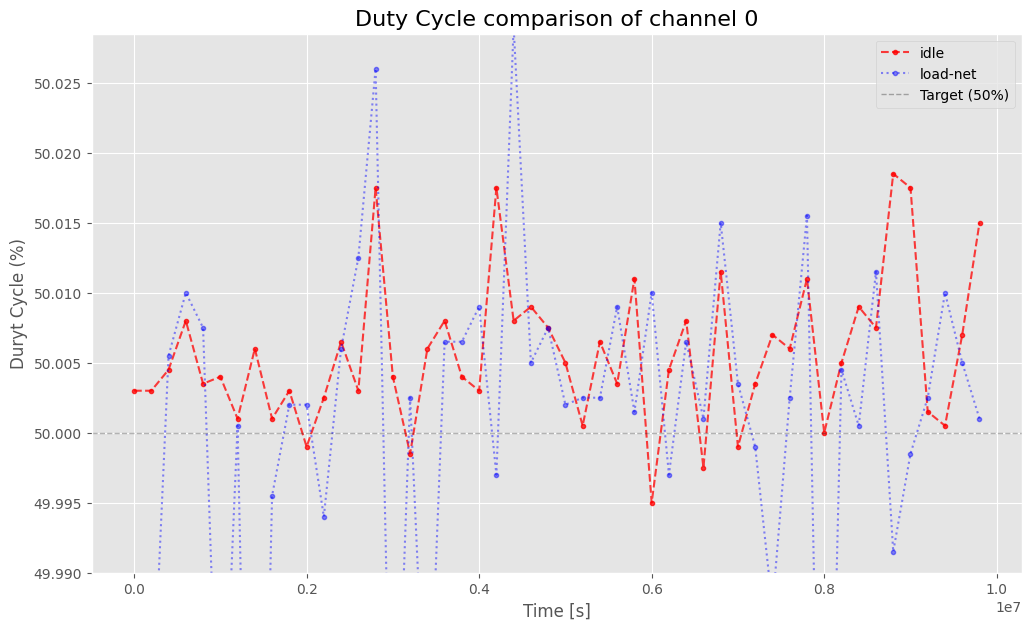

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_duty_cycle_default_idle_load-net_1.png'


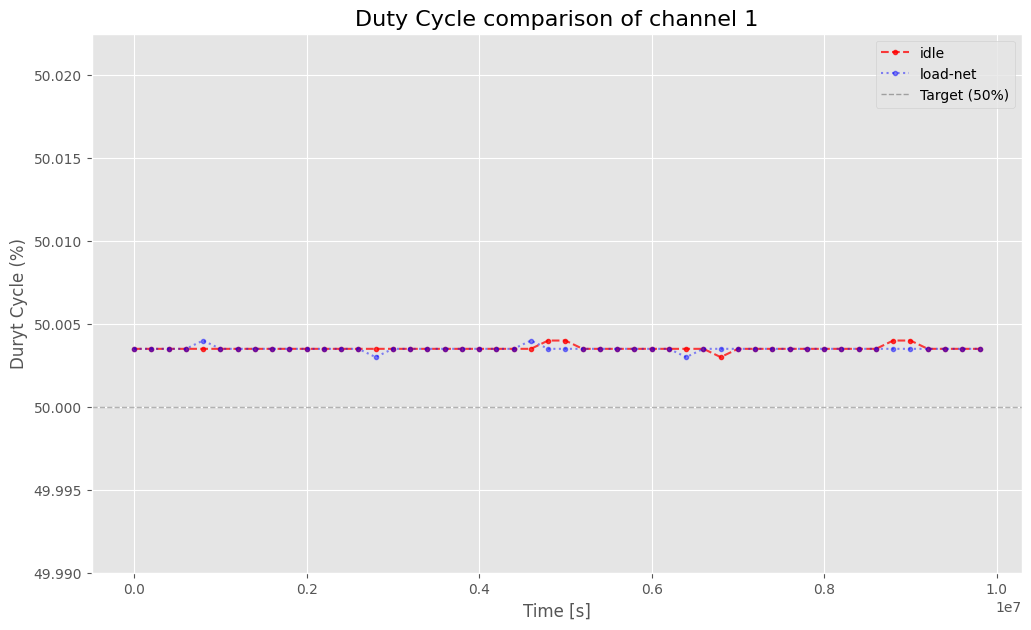

In [8]:
proc.plot_duty_cycle_combined(plots[0], plots[1], 0, show=True, y_lim=(49.99, 50.0285))
proc.plot_duty_cycle_combined(plots[0], plots[1], 1, show=True, y_lim=(49.99, 50.0225))

Stacked bar plot saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_bar_default_idle_proc_interrupts.png'


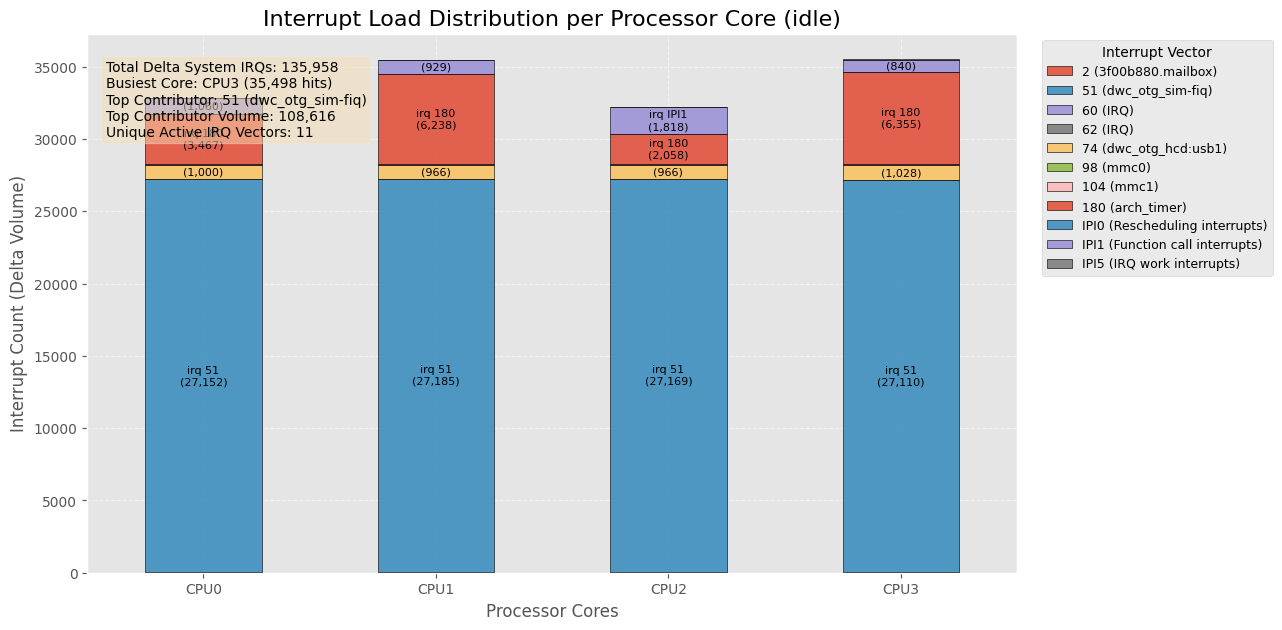

Stacked bar plot saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-22-13-35-54/jitter_bar_default_load-net_proc_interrupts.png'


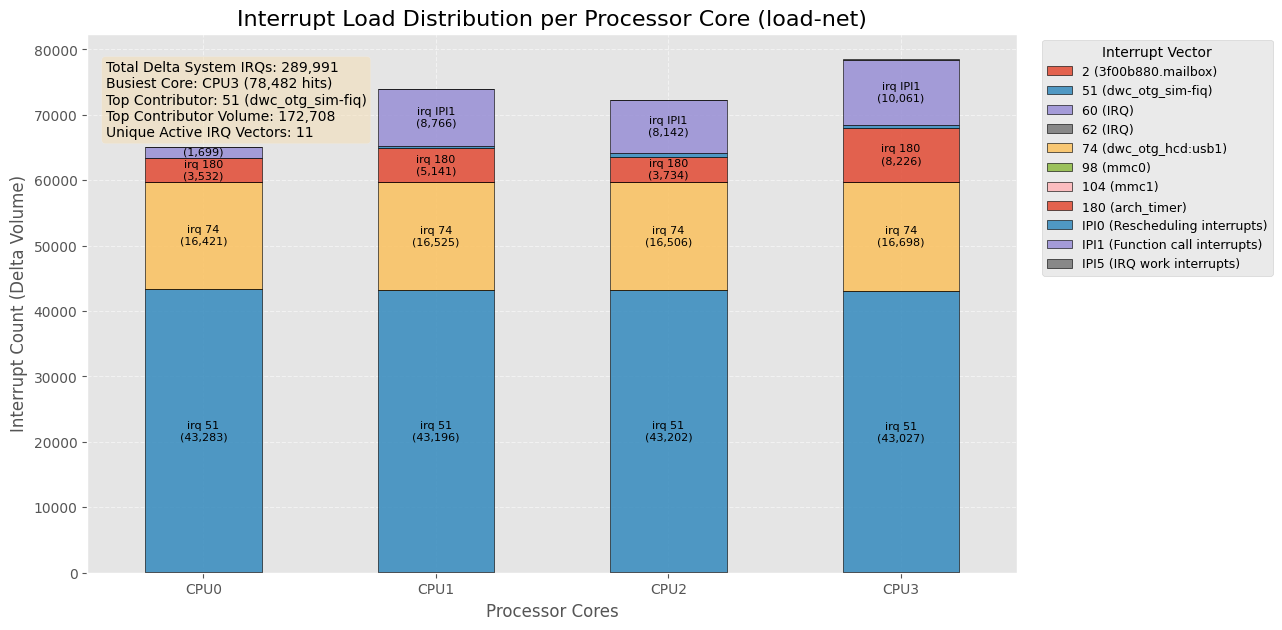

In [17]:
proc.plot_interrupts_stacked_bar(plots[0], show=True)
proc.plot_interrupts_stacked_bar(plots[1], show=True)